In [1]:
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

import skimage
import scipy.ndimage
from sklearn.manifold import Isomap
from scipy.interpolate import make_splrep

from fibermorph.fibermorph import make_subdirectory, pixel_length_correction, list_images, convert
from tqdm import tqdm
import pandas as pd

from datetime import datetime
from joblib import Parallel, delayed

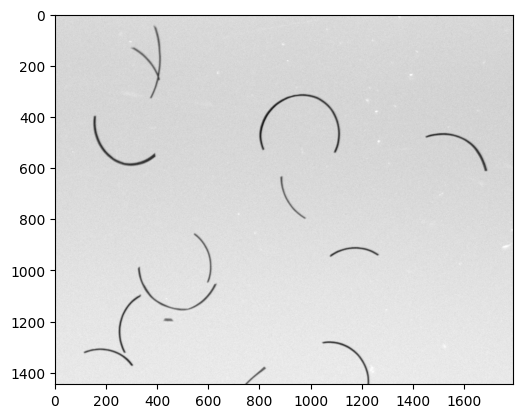

In [40]:
resolution = 132
min_size = int(0.5 * resolution)
# read a grayscale image
input_path = Path("data/curv/004_demo_curv.tiff")
raw_img = Image.open(input_path)
# convert to numpy array
img = np.array(raw_img.convert("L"))

plt.imshow(img, cmap="gray")

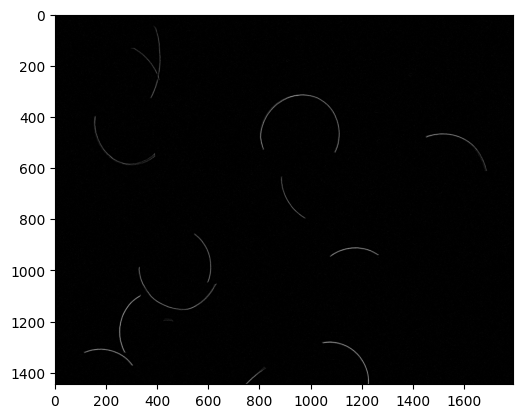

In [41]:
# filter the image
filtered_img = skimage.filters.frangi(img)
adjust_filtered_img = skimage.exposure.adjust_log(filtered_img)

plt.imshow(adjust_filtered_img, cmap="gray")

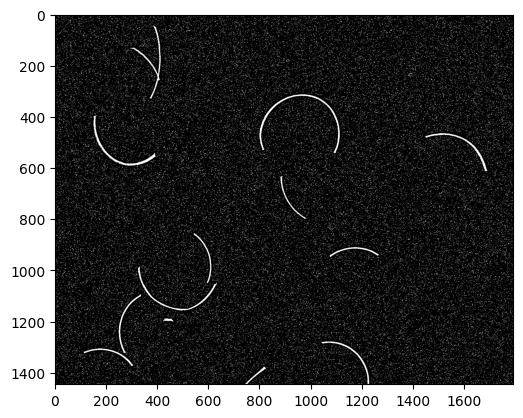

In [42]:
# threshold the image
thres_img = adjust_filtered_img > skimage.filters.threshold_otsu(adjust_filtered_img) * 0.1

plt.imshow(thres_img, cmap="gray")

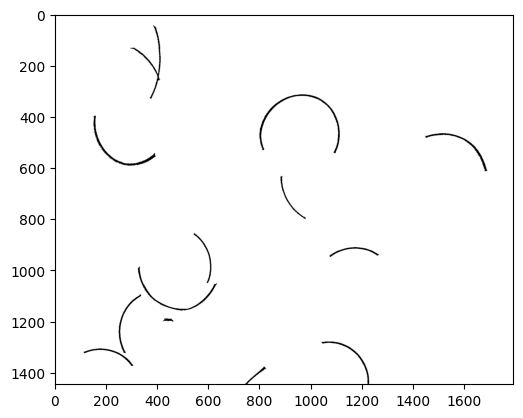

In [43]:
removed_img = skimage.morphology.remove_small_objects(thres_img, min_size=min_size, connectivity=2)
plt.imshow(skimage.util.invert(removed_img), cmap="gray")

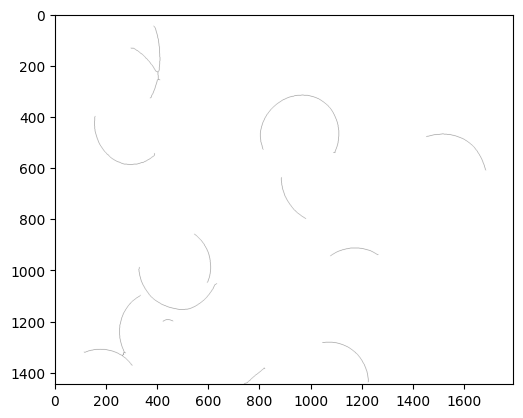

In [45]:
binary_img = skimage.morphology.binary_dilation(removed_img, footprint=skimage.morphology.disk(5))

ske_img = skimage.morphology.skeletonize(binary_img)
plt.imshow(skimage.util.invert(ske_img), cmap="gray")

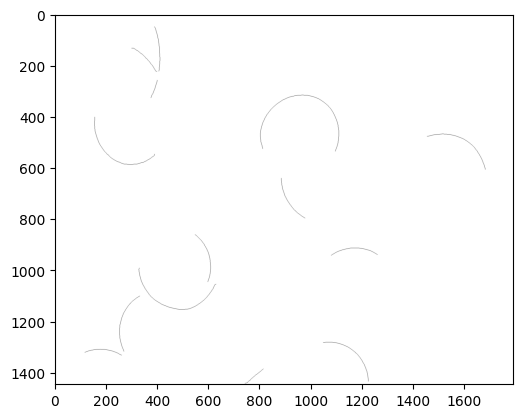

In [46]:
conv_kernel = np.ones((3, 3), dtype=np.uint8)
conv_image = scipy.ndimage.convolve(ske_img.astype(np.uint8), conv_kernel, mode="constant", cval=0.0)
conv_image = np.where(ske_img, conv_image, 0)

# 0 = background, 2 = edge, 3 = middle, 4,5 = junction
edge_mark = ~np.isin(conv_image, [0, 3])
conv_kernel2 = np.ones((5, 5), dtype=np.uint8)
edge_mark = scipy.ndimage.convolve(edge_mark.astype(np.uint8), conv_kernel2, mode="constant", cval=0.0)
edge_mark = np.where(edge_mark, 1, 0)

prune_img = np.where(edge_mark, False, ske_img)
prune_img = skimage.morphology.remove_small_objects(prune_img, min_size=min_size, connectivity=2)
plt.imshow(skimage.util.invert(prune_img), cmap="gray")


In [47]:
# label the image
label_img, num_labels = skimage.measure.label(prune_img, return_num=True)

morph = skimage.measure.regionprops(label_img)

In [48]:
num_labels

14

In [11]:
# segment the longitudinal hair image
def segment_curv_image(img, min_size=50, output_path=None, name=None, save_img=False):
    """Segment the image to isolate the hair fibers from the background.
    
    Parameters
    ----------
    img : np.ndarray
        Grayscale image.
    min_size : int
        Minimum size of the object to be segmented.
    output_path : pathlib object
        A path to the output directory.
    name : str
        Input image name.
    save_img : bool
        True or false for saving image.

    Returns
    -------
    np.ndarray
        Segmented binary image with isolated hair fibers.
    """

    # filter the image
    img = skimage.filters.frangi(img)
    img = skimage.exposure.adjust_log(img)
    # convert to binary
    # threshold the image using a conservative cutoff
    thres_img = img > skimage.filters.threshold_otsu(img) * 0.1
    # remove small objects
    binary_img = skimage.morphology.remove_small_objects(thres_img, min_size=min_size, connectivity=2)
    # dilate the image
    dilate_img = skimage.morphology.binary_dilation(binary_img, footprint=skimage.morphology.disk(3))
    # skeletonize the image
    ske_img = skimage.morphology.skeletonize(dilate_img)
    
    # prune the image
    # remove edge pixels and branch points of the skeleton
    conv_kernel = np.ones((3, 3), dtype=np.uint8)
    conv_image = scipy.ndimage.convolve(ske_img.astype(np.uint8), conv_kernel, mode="constant", cval=0.0)
    conv_image = np.where(ske_img, conv_image, 0)

    # 0 = background, 2 = edge, 3 = middle, 4,5 = junction
    edge_mark = ~np.isin(conv_image, [0, 3])
    conv_kernel2 = np.ones((5, 5), dtype=np.uint8)
    edge_mark = scipy.ndimage.convolve(edge_mark.astype(np.uint8), conv_kernel2, mode="constant", cval=0.0)
    edge_mark = np.where(edge_mark, 1, 0)

    prune_img = np.where(edge_mark, False, ske_img)
    prune_img = skimage.morphology.remove_small_objects(prune_img, min_size=min_size, connectivity=2)

    if save_img:
        saved_img = skimage.morphology.binary_dilation(prune_img, footprint=skimage.morphology.disk(2))
        img_inv = skimage.util.invert(saved_img)
        output_path = make_subdirectory(output_path, append_name="segmented")
        im = Image.fromarray(img_inv)
        im.save(output_path.joinpath(name + ".tiff"))

    return prune_img


In [12]:
# calculate the curvature of a single hair fragment
def cal_curv_single_hair(single_hair, resolution):
    """Calculate the mean curvature of a single hair fragment.

    Parameters
    ----------
    single_hair : Iterable
        A list of RegionProperties (most importantly, coordinates) from scikit-image regionprops function.
    resolution : int
        Number of pixels per mm.

    Returns
    -------
    float
        The mean curvature of the hair fragment.

    """
    
    # get the coordinates of the hair fragment
    coords = single_hair.coords

    # fit a principal curve to the coordinates

    # use Isomap to fit a curve
    # Isomap is a non-linear dimensionality reduction technique
    isomap = Isomap(n_neighbors=5, n_components=1)
    hair_isomap = isomap.fit_transform(coords).flatten()
    # sort the coordinates
    indices = np.argsort(hair_isomap)
    sorted_hair_isomap = hair_isomap[indices]
    sorted_coords = coords[indices, :]
    # fit a spline to the coordinates
    spl_x = make_splrep(sorted_hair_isomap, sorted_coords[:, 0], s=len(sorted_hair_isomap))
    spl_y = make_splrep(sorted_hair_isomap, sorted_coords[:, 1], s=len(sorted_hair_isomap))

    # calculate the first and second derivatives of the spline
    dx = spl_x.derivative(1)(sorted_hair_isomap)
    dy = spl_y.derivative(1)(sorted_hair_isomap)
    ddx = spl_x.derivative(2)(sorted_hair_isomap)
    ddy = spl_y.derivative(2)(sorted_hair_isomap)
    # calculate the curvature
    curvature = np.abs(dx * ddy - dy * ddx) / (dx ** 2 + dy ** 2) ** (3 / 2) * resolution
    # calculate the mean curvature
    mean_curvature = np.mean(curvature)

    return mean_curvature

In [13]:
# calculate the curvature of a longitudinal hair image
def cal_curvature(input_file, output_path, resolution, save_img=True, verbose=True):
    """Takes directory of a grayscale tiff image and analyzes curvature for all hair fragments in the image.

    Parameters
    ----------
    input_file : pathlib Path object
        Path to image that needs to be analyzed.
    output_path : pathlib object
        Output path as pathlib object.
    resolution : float
        Number of pixels per mm in original image.
    save_img : bool
        True or false for saving images for image processing steps.
    verbose : bool
        True or False for whether to save spreadsheets with curvature values for each image.

    Returns
    -------
    pd.DataFrame
        [ID, mean_curvature, total_length]
    ID : str
        The name of the image.
    mean_curvature : float
        The mean curvature of the entire image.
        The mean curvature of the entire image is calculated by taking the weighted mean of the curvatures of each hair fragment, where the weights are the lengths of the hair fragments.
    total_length : float
        The cumulative length of the hair fragments is also returned.
    """

    # read the grayscale image
    raw_img = Image.open(input_file)
    # convert to numpy array
    img = np.array(raw_img.convert("L"))

    name = input_file.stem
    # the minimum size of the object to be segmented
    min_size = int(resolution * 0.5)

    # segment the image
    segmented_img = segment_curv_image(img, min_size=min_size, output_path=output_path, name=name, save_img=save_img)
    # print("\n Done segmenting {}".format(name))

    # label the image
    label_img = skimage.measure.label(segmented_img)
    # get the region properties
    morph = skimage.measure.regionprops(label_img)

    # calculate the mean curvature of each hair fragment
    curvatures = [cal_curv_single_hair(single_hair, resolution) for single_hair in morph]
    # print("\n Done calculating curvature for {}".format(name))
    # get the length of each hair fragment
    lengths = [pixel_length_correction(single_hair) / resolution for single_hair in morph]

    if verbose:
        # create a dataframe with the curvature and length of each hair fragment
        df = pd.DataFrame({"curvature": curvatures, "length": lengths})
        # save the dataframe to a csv file
        output_path = make_subdirectory(output_path, append_name="analysis")
        df.to_csv(output_path.joinpath(name + "_curvature.csv"))

    # calculate the weighted mean curvature of the entire image
    if len(morph) == 0:
        # if there are no hair fragments, return NaN
        weighted_mean_curvature = np.nan
    else:
        weighted_mean_curvature = np.sum(np.array(curvatures) * np.array(lengths)) / np.sum(lengths)

    return pd.DataFrame({"ID": [name], 
                         "mean_curvature": [weighted_mean_curvature], 
                         "total_length": [np.sum(lengths)]})

    

In [14]:
input_path = Path("data/curv/004_demo_curv.tiff")
output_path = Path("output/curv")
resolution = 132

# test the function
curv_df = cal_curvature(input_path, output_path, resolution, save_img=True, verbose=True)

curv_df

,ID,mean_curvature,total_length
0,004_demo_curv,0.800216,26.846117


846.0


In [15]:
input_path = Path("data/curv/027_demo_nocurv.tiff")
output_path = Path("output/curv")
resolution = 132

# test the function
nocurv_df = cal_curvature(input_path, output_path, resolution, save_img=True, verbose=True)

nocurv_df

,ID,mean_curvature,total_length
0,027_demo_nocurv,0.02829,23.061874


In [16]:
pd.concat([curv_df, nocurv_df], axis=0)

,ID,mean_curvature,total_length
0,004_demo_curv,0.800216,26.846117
0,027_demo_nocurv,0.028290,23.061874


In [17]:
# calculate the curvature of a longitudinal hair image
def curvature(input_directory, main_output_path, jobs=1, resolution=132, save_img=True, verbose=True):
    """Takes directory of grayscale tiff images and analyzes curvature for all hair fragments in the image.

    Parameters
    ----------
    input_directory : str or pathlib object
        Input directory path as str or pathlib object.
    main_output_path : str or pathlib object
        Main output path as str or pathlib object.
    jobs : int
        Number of jobs to run in parallel.
    resolution : float
        Number of pixels per mm in original image.
    save_img : bool
        True or false for saving images for image processing steps.
    verbose : bool
        True or False for whether to save spreadsheets with curvature values for each image.

    Returns
    -------
    void
        The function saves the output files in the specified output directory.

    """

    total_start = datetime.now()

    # create an output directory for the analyses
    jetzt = datetime.now()
    timestamp = jetzt.strftime("%b%d_%H%M_")
    dir_name = str(timestamp + "fibermorph_curvature")
    output_path = make_subdirectory(main_output_path, append_name=dir_name)

    file_list = list_images(input_directory)

    curv_list = Parallel(n_jobs=jobs, verbose=0)(
        delayed(cal_curvature)(
            input_file,
            output_path,
            resolution,
            save_img=save_img,
            verbose=verbose,
        )
        for input_file in file_list
        )
    
    curv_df = pd.concat(curv_list, axis=0)
    curv_df.to_csv(output_path.joinpath("curvature_summary.csv"))

    total_end = datetime.now()
    total_time = total_end - total_start
    print("Total time: {}".format(convert(total_time.total_seconds())))


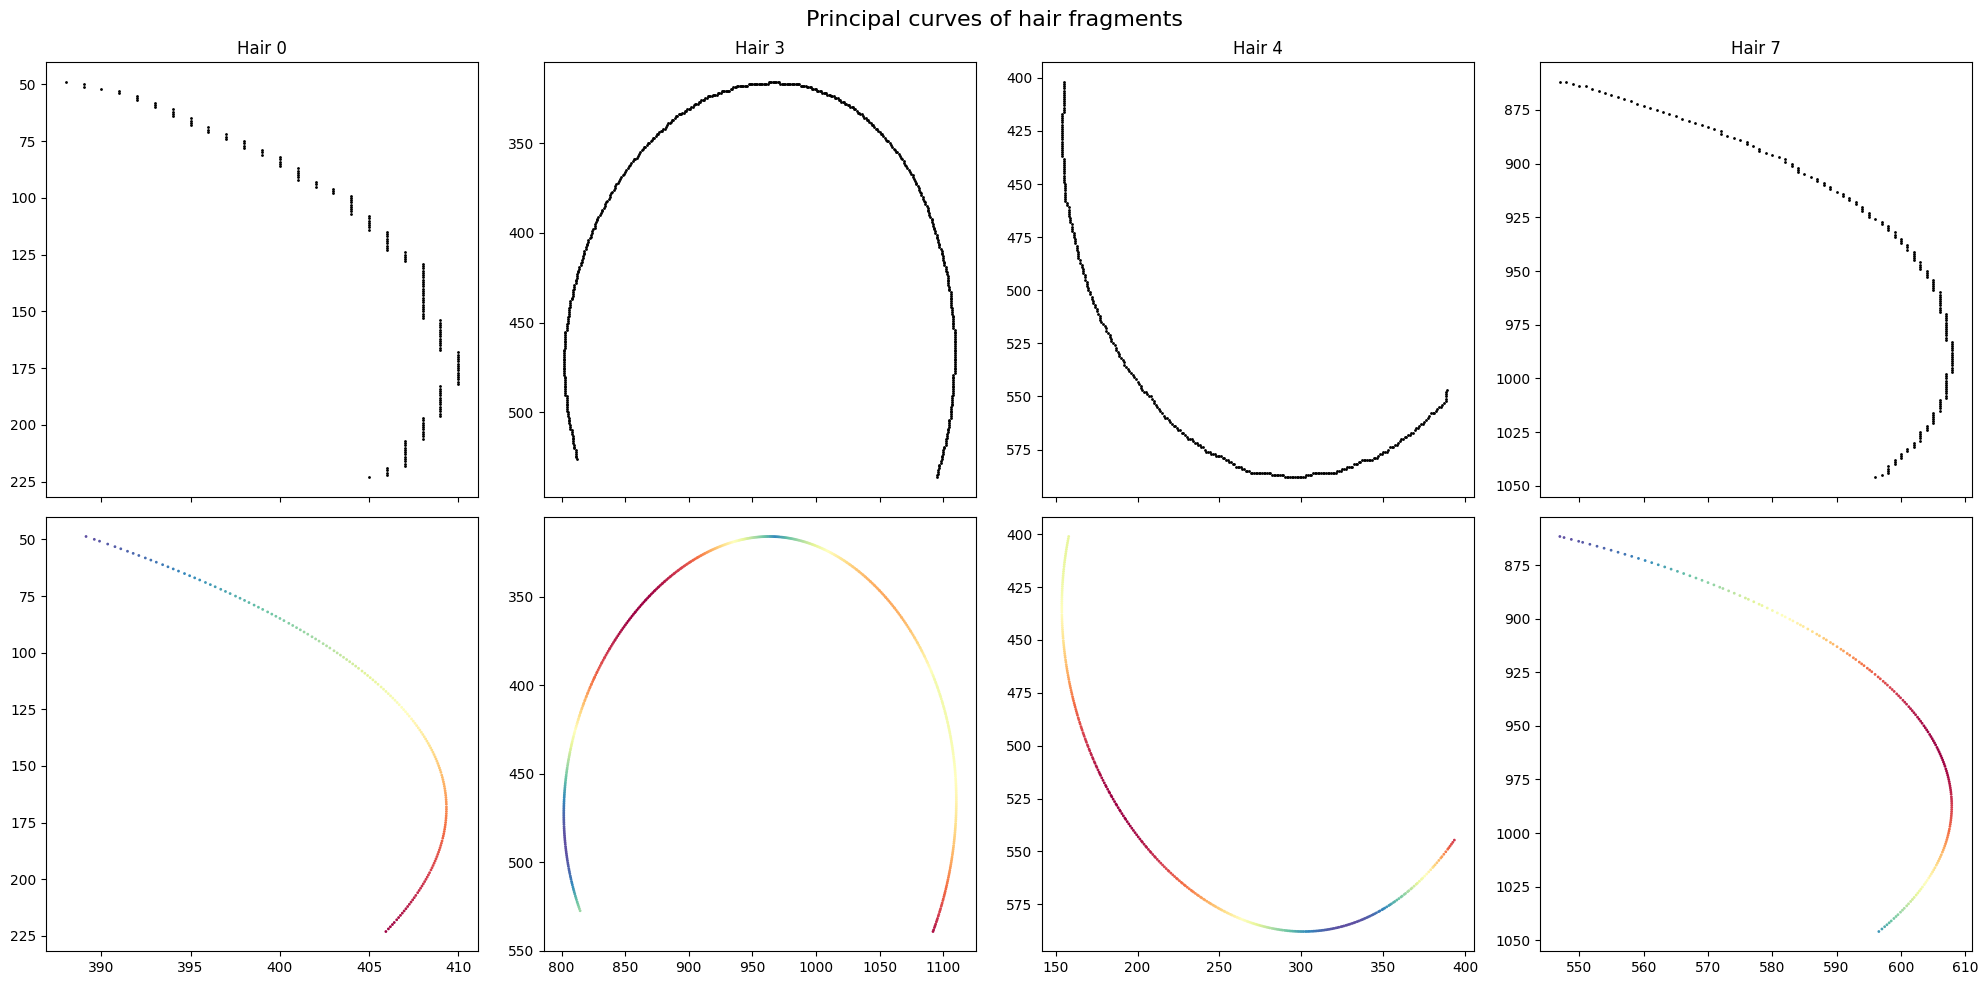

In [51]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10), sharex='col')
indices_hair = [0, 3, 4, 7]
for i in range(4):
    example_hair = morph[indices_hair[i]]
    coords = example_hair.coords
    
    axs[0, i].scatter(example_hair.coords[:, 1], example_hair.coords[:, 0], s=1, color='black')
    axs[0, i].invert_yaxis()
    axs[0, i].set_title(f"Hair {indices_hair[i]}")

    # fit principal curves
    isomap = Isomap(n_neighbors=5, n_components=1)
    hair_isomap = isomap.fit_transform(coords).flatten()
    indices = np.argsort(hair_isomap)
    hair_isomap = hair_isomap[indices]
    coords = coords[indices, :]
    

    spl_x = make_splrep(hair_isomap, coords[:, 0], s=len(hair_isomap))
    spl_y = make_splrep(hair_isomap, coords[:, 1], s=len(hair_isomap))
    prin_curve = np.stack((spl_x(hair_isomap), spl_y(hair_isomap)), axis=1)
    dx = spl_x.derivative(1)(hair_isomap)
    dy = spl_y.derivative(1)(hair_isomap)
    ddx = spl_x.derivative(2)(hair_isomap)
    ddy = spl_y.derivative(2)(hair_isomap)
    curvature = np.abs(dx * ddy - dy * ddx) / (dx ** 2 + dy ** 2) ** (3 / 2) * resolution

    axs[1, i].scatter(prin_curve[:, 1], prin_curve[:, 0], s=1, c=curvature, cmap=plt.cm.Spectral)
    axs[1, i].invert_yaxis()
    # axs[1, i].set_title(f"Hair {indices_hair[i]}")

fig.suptitle("Principal curves of hair fragments", fontsize=16)
plt.tight_layout()
plt.savefig("output/report/principal_curves.png", dpi=500)
plt.show()

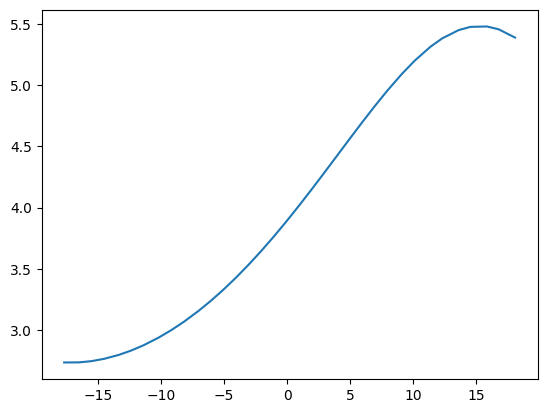

In [41]:
dx = spl_x.derivative(1)(hair_isomap)
dy = spl_y.derivative(1)(hair_isomap)
ddx = spl_x.derivative(2)(hair_isomap)
ddy = spl_y.derivative(2)(hair_isomap)
curvature = np.abs(dx * ddy - dy * ddx) / (dx ** 2 + dy ** 2) ** (3 / 2) * resolution
plt.plot(hair_isomap, curvature)
mean_curvature = np.mean(curvature)
print(mean_curvature)